In [1]:
# Celda 1 — Instalar dependencias y configuración
!pip install umap-learn==0.5.6 -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import umap
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from google.colab import drive
import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Setup completado.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 1.1 MB/s eta 0:00:00
Setup completado.


In [2]:
# Celda 2 — Cargar datos y modelos top 2 desde Drive
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/ProyectoHIGGS/'

X_train = np.load(DRIVE_PATH + 'X_train.npy')
X_val   = np.load(DRIVE_PATH + 'X_val.npy')
X_test  = np.load(DRIVE_PATH + 'X_test.npy')
y_train = np.load(DRIVE_PATH + 'y_train.npy')
y_val   = np.load(DRIVE_PATH + 'y_val.npy')
y_test  = np.load(DRIVE_PATH + 'y_test.npy')
FEATURES = np.load(DRIVE_PATH + 'feature_names.npy').tolist()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

# Cargar top 2 modelos entrenados en 03_modelos
top2_nombres = np.load(DRIVE_PATH + 'top2_modelos.npy', allow_pickle=True).tolist()
print(f"\nTop 2 modelos: {top2_nombres}")

top2_objetos = {}
for nombre in top2_nombres:
    safe = nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').replace('=', '').replace(',', '')
    with open(DRIVE_PATH + f'modelo_{safe}.pkl', 'rb') as f:
        top2_objetos[nombre] = pickle.load(f)
    print(f"  Cargado: {nombre}")

Mounted at /content/drive
Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)
Features (28): ['lepton_pt', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude', 'missing_energy_phi', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_b_tag', 'jet2_pt', 'jet2_eta', 'jet2_phi', 'jet2_b_tag', 'jet3_pt', 'jet3_eta', 'jet3_phi', 'jet3_b_tag', 'jet4_pt', 'jet4_eta', 'jet4_phi', 'jet4_b_tag', 'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

Top 2 modelos: ['Red Neuronal (MLP)', 'XGBoost']
  Cargado: Red Neuronal (MLP)
  Cargado: XGBoost


In [3]:
# Celda 3 — Función de evaluación con IC (scalers por fold, sin leakage)
def evaluar_modelo_cv(model, X_tr, y_tr, X_v, y_v, X_te, y_te, nombre, k=5):
    """
    Evalúa modelo con K-Fold CV estratificado. Scaler se ajusta dentro de cada
    fold para evitar data leakage. Reporta AUC-ROC, F1, Accuracy, Precision y Recall
    con intervalos de confianza (media ± 2σ) en train CV, val y test.
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_tr, y_tr):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_tr[tr_idx])
        X_vl_fold = scaler_cv.transform(X_tr[vl_idx])
        # Fit con fallback para modelos que requieren eval_set (XGBoost, LightGBM, CatBoost)
        try:
            model.fit(X_tr_fold, y_tr[tr_idx])
        except (ValueError, TypeError):
            X_sub_tr, X_sub_ev, y_sub_tr, y_sub_ev = train_test_split(
                X_tr_fold, y_tr[tr_idx], test_size=0.1,
                stratify=y_tr[tr_idx], random_state=42
            )
            model.fit(X_sub_tr, y_sub_tr, eval_set=[(X_sub_ev, y_sub_ev)])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_tr[vl_idx], y_prob))
        f1_folds.append(f1_score(y_tr[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_tr[vl_idx], y_pred))
        prec_folds.append(precision_score(y_tr[vl_idx], y_pred))
        rec_folds.append(recall_score(y_tr[vl_idx], y_pred))

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_v_sc  = scaler.transform(X_v)
    X_te_sc = scaler.transform(X_te)
    # Fit final con fallback para modelos que requieren eval_set
    try:
        model.fit(X_tr_sc, y_tr)
    except (ValueError, TypeError):
        X_sub_tr, X_sub_ev, y_sub_tr, y_sub_ev = train_test_split(
            X_tr_sc, y_tr, test_size=0.1, stratify=y_tr, random_state=42
        )
        model.fit(X_sub_tr, y_sub_tr, eval_set=[(X_sub_ev, y_sub_ev)])

    return {
        'Modelo': nombre,
        'AUC_CV_mean': np.mean(auc_folds), 'AUC_CV_std': np.std(auc_folds),
        'F1_CV_mean':  np.mean(f1_folds),  'F1_CV_std':  np.std(f1_folds),
        'Acc_CV_mean': np.mean(acc_folds), 'Acc_CV_std': np.std(acc_folds),
        'Precision_CV_mean': np.mean(prec_folds), 'Precision_CV_std': np.std(prec_folds),
        'Recall_CV_mean': np.mean(rec_folds), 'Recall_CV_std': np.std(rec_folds),
        'AUC_val': roc_auc_score(y_v,  model.predict_proba(X_v_sc)[:, 1]),
        'F1_val':  f1_score(y_v,  model.predict(X_v_sc)),
        'Acc_val': accuracy_score(y_v, model.predict(X_v_sc)),
        'Precision_val': precision_score(y_v, model.predict(X_v_sc)),
        'Recall_val': recall_score(y_v, model.predict(X_v_sc)),
        'AUC_test': roc_auc_score(y_te, model.predict_proba(X_te_sc)[:, 1]),
        'F1_test':  f1_score(y_te,  model.predict(X_te_sc)),
        'Acc_test': accuracy_score(y_te, model.predict(X_te_sc)),
        'Precision_test': precision_score(y_te, model.predict(X_te_sc)),
        'Recall_test': recall_score(y_te, model.predict(X_te_sc)),
    }


def tabla_resultados(resultados_lista):
    """Formatea lista de resultados como DataFrame con IC."""
    rows = []
    for r in resultados_lista:
        rows.append({
            'Modelo': r['Modelo'],
            'AUC CV (mean±2σ)': f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            'AUC Val':  f"{r['AUC_val']:.3f}",
            'AUC Test': f"{r['AUC_test']:.3f}",
            'F1 Test':  f"{r['F1_test']:.3f}",
            'Acc Test': f"{r['Acc_test']:.3f}",
            'Precision Test': f"{r['Precision_test']:.3f}",
            'Recall Test': f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index('Modelo')

In [4]:
# Celda 4 — Sección 5.1: Análisis individual de variables
# Índice de discriminación: d-prime (d') = |μ1 - μ0| / sqrt((σ1² + σ0²) / 2)
# y correlación punto-biserial con la etiqueta binaria

print("=" * 65)
print("SECCIÓN 5.1 — Análisis individual de variables")
print("=" * 65)

scaler_global = StandardScaler()
X_train_sc = scaler_global.fit_transform(X_train)

disc_stats = []
for i, feat in enumerate(FEATURES):
    x0 = X_train_sc[y_train == 0, i]
    x1 = X_train_sc[y_train == 1, i]
    mu0, mu1 = x0.mean(), x1.mean()
    s0,  s1  = x0.std(),  x1.std()
    d_prime = abs(mu1 - mu0) / np.sqrt((s1**2 + s0**2) / 2 + 1e-12)
    r_pb, p_val = stats.pointbiserialr(y_train, X_train_sc[:, i])
    disc_stats.append({
        'Feature': feat,
        "d' (discriminación)": round(d_prime, 4),
        '|r_pb| (correlación)': round(abs(r_pb), 4),
        'p-valor': round(p_val, 6),
    })

df_disc = pd.DataFrame(disc_stats).sort_values("d' (discriminación)", ascending=False)
print(df_disc.to_string(index=False))

# Umbral: features con d' < 0.1 son candidatas a eliminar
UMBRAL_D = 0.1
candidatas_eliminar = df_disc[df_disc["d' (discriminación)"] < UMBRAL_D]['Feature'].tolist()
print(f"\nFeatures candidatas a eliminarse (d' < {UMBRAL_D}): {candidatas_eliminar}")

# Guardar tabla
df_disc.to_csv(DRIVE_PATH + 'tabla_discriminacion_variables.csv', index=False)
print("\nTabla guardada en Drive.")

SECCIÓN 5.1 — Análisis individual de variables
                 Feature  d' (discriminación)  |r_pb| (correlación)  p-valor
                    m_bb               0.3057                0.1529 0.000000
                  m_wwbb               0.2466                0.1228 0.000000
missing_energy_magnitude               0.2014                0.1007 0.000000
                   m_wbb               0.1306                0.0654 0.000000
                 jet1_pt               0.1148                0.0572 0.000000
              jet2_b_tag               0.1034                0.0515 0.000000
               lepton_pt               0.0947                0.0475 0.000000
                 jet4_pt               0.0796                0.0396 0.000000
                   m_jlv               0.0628                0.0315 0.000000
                   m_jjj               0.0553                0.0275 0.000000
              jet3_b_tag               0.0494                0.0246 0.000000
                 jet2_pt     

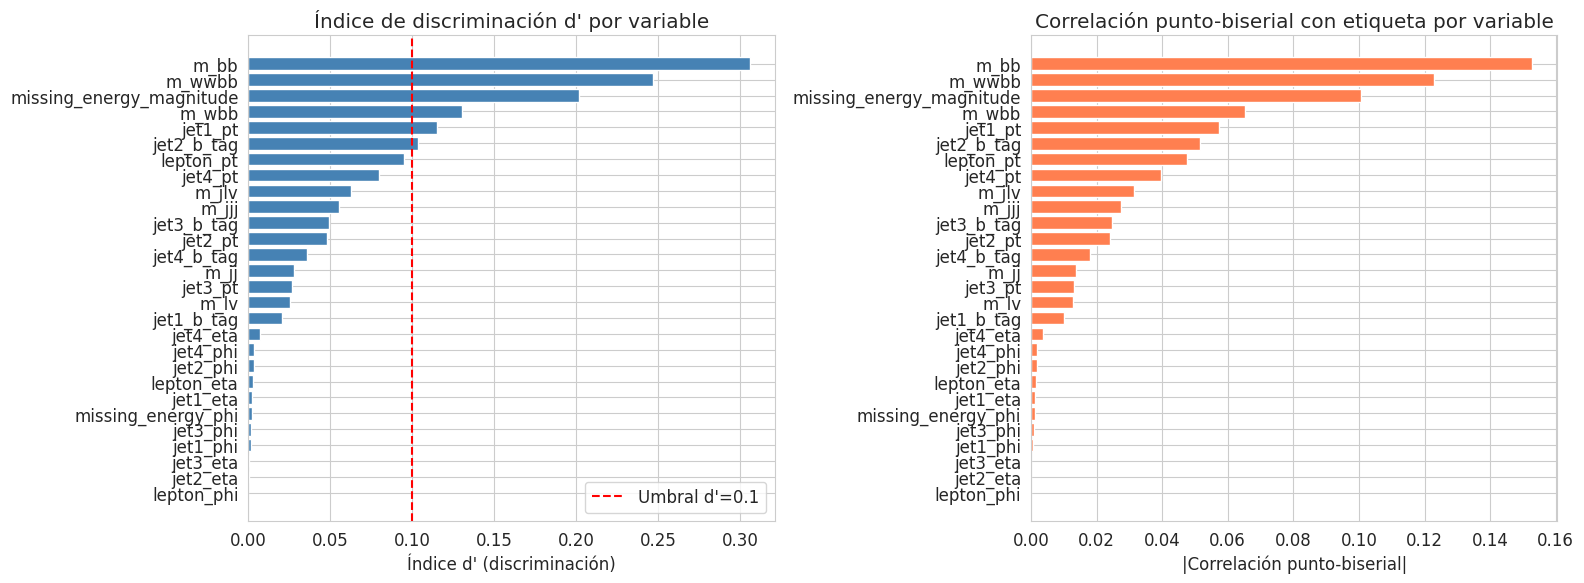

Figura guardada.


In [5]:
# Celda 5 — Gráfica de barras: capacidad discriminativa por variable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# d' por feature (ordenado)
df_sorted = df_disc.sort_values("d' (discriminación)", ascending=True)
axes[0].barh(df_sorted['Feature'], df_sorted["d' (discriminación)"], color='steelblue')
axes[0].axvline(UMBRAL_D, color='red', linestyle='--', label=f'Umbral d\'={UMBRAL_D}')
axes[0].set_xlabel("Índice d' (discriminación)")
axes[0].set_title("Índice de discriminación d' por variable")
axes[0].legend()

# |r_pb| por feature
df_sorted2 = df_disc.sort_values('|r_pb| (correlación)', ascending=True)
axes[1].barh(df_sorted2['Feature'], df_sorted2['|r_pb| (correlación)'], color='coral')
axes[1].set_xlabel('|Correlación punto-biserial|')
axes[1].set_title('Correlación punto-biserial con etiqueta por variable')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_discriminacion_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

In [6]:
# Celda — Sección 5.1+: Selección de features (eliminación y re-evaluación)
# La guía pide "identificar candidatas a ser eliminadas" (hecho en celda 4).
# Aquí: eliminar las features débiles y re-evaluar los top-2 modelos.

print("=" * 65)
print("SECCIÓN 5.1+ — Eliminación de features débiles y re-evaluación")
print("=" * 65)

# Seleccionar features con d' por debajo del percentil 25
umbral_d = np.percentile(df_disc["d' (discriminación)"], 25)
features_bajas = df_disc[df_disc["d' (discriminación)"] <= umbral_d]['Feature'].tolist()
features_altas = df_disc[df_disc["d' (discriminación)"] > umbral_d]['Feature'].tolist()

print(f"Umbral d' (percentil 25): {umbral_d:.4f}")
print(f"Features eliminadas ({len(features_bajas)}): {features_bajas}")
print(f"Features conservadas ({len(features_altas)}): {len(features_altas)} variables")

# Crear datasets reducidos
indices_altas = [FEATURES.index(f) for f in features_altas]
X_train_sel = X_train[:, indices_altas]
X_val_sel   = X_val[:, indices_altas]
X_test_sel  = X_test[:, indices_altas]
print(f"\nDimensiones reducidas — Train: {X_train_sel.shape}, Val: {X_val_sel.shape}, Test: {X_test_sel.shape}")
print(f"Reducción: {X_train.shape[1]} → {X_train_sel.shape[1]} features "
      f"({100 - 100*X_train_sel.shape[1]//X_train.shape[1]}% menos)")

# Cargar resultados originales para comparación
try:
    df_orig = pd.read_csv(DRIVE_PATH + 'tabla_comparativa_modelos.csv', index_col='Modelo')
except:
    df_orig = None

# Re-evaluar top-2 modelos con features reducidas
resultados_sel = {}
for nombre in top2_nombres:
    obj = top2_objetos[nombre]
    model_clone = pickle.loads(pickle.dumps(obj['model']))
    r = evaluar_modelo_cv(model_clone, X_train_sel, y_train, X_val_sel, y_val,
                           X_test_sel, y_test, f"{nombre} (sel. features)")
    resultados_sel[nombre] = r
    auc_str = ""
    if df_orig is not None and nombre in df_orig.index:
        auc_orig = float(df_orig.loc[nombre, 'AUC Test'])
        auc_str = f" (vs {auc_orig:.4f} original, Δ={r['AUC_test'] - auc_orig:+.4f})"
    print(f"  {nombre}: AUC test = {r['AUC_test']:.4f}{auc_str}")

# Tabla comparativa
print("\n--- Comparación: Features completas vs Features seleccionadas ---")
filas_sel = []
for nombre in top2_nombres:
    r_sel = resultados_sel[nombre]
    row = {
        'Modelo': nombre,
        'AUC Test (sel. features)': f"{r_sel['AUC_test']:.4f}",
        'Features usadas': len(features_altas),
    }
    if df_orig is not None and nombre in df_orig.index:
        auc_orig = float(df_orig.loc[nombre, 'AUC Test'])
        row['AUC Test (28 features)'] = f"{auc_orig:.4f}"
        row['Δ AUC'] = f"{r_sel['AUC_test'] - auc_orig:+.4f}"
    filas_sel.append(row)
.
df_sel = pd.DataFrame(filas_sel).set_index('Modelo')
print(df_sel.to_string())
df_sel.to_csv(DRIVE_PATH + 'tabla_seleccion_features.csv')
print("\ntabla_seleccion_features.csv guardado.")

# Guardar lista de features seleccionadas
np.save(DRIVE_PATH + 'features_seleccionadas.npy', np.array(features_altas))
print("features_seleccionadas.npy guardado.")

SECCIÓN 5.1+ — Eliminación de features débiles y re-evaluación
Umbral d' (percentil 25): 0.0028
Features eliminadas (7): ['missing_energy_phi', 'jet1_eta', 'jet3_phi', 'jet1_phi', 'jet2_eta', 'jet3_eta', 'lepton_phi']
Features conservadas (21): 21 variables

Dimensiones reducidas — Train: (350000, 21), Val: (75000, 21), Test: (75000, 21)
Reducción: 28 → 21 features (25% menos)
  Red Neuronal (MLP): AUC test = 0.8225 (vs 0.8260 original, Δ=-0.0035)
[0]	validation_0-auc:0.73363
[1]	validation_0-auc:0.75742
[2]	validation_0-auc:0.77227
[3]	validation_0-auc:0.78519
[4]	validation_0-auc:0.78919
[5]	validation_0-auc:0.79229
[6]	validation_0-auc:0.79544
[7]	validation_0-auc:0.79701
[8]	validation_0-auc:0.79845
[9]	validation_0-auc:0.80112
[10]	validation_0-auc:0.80243
[11]	validation_0-auc:0.80334
[12]	validation_0-auc:0.80352
[13]	validation_0-auc:0.80470
[14]	validation_0-auc:0.80586
[15]	validation_0-auc:0.80639
[16]	validation_0-auc:0.80738
[17]	validation_0-auc:0.80823
[18]	validation_0-

SECCIÓN 5.2 — Extracción de características lineal (PCA)
Número original de features: 28
Componentes para explicar 95% de varianza: 23
Porcentaje de reducción: 17.9%
Varianza explicada con 23 componentes: 95.93%


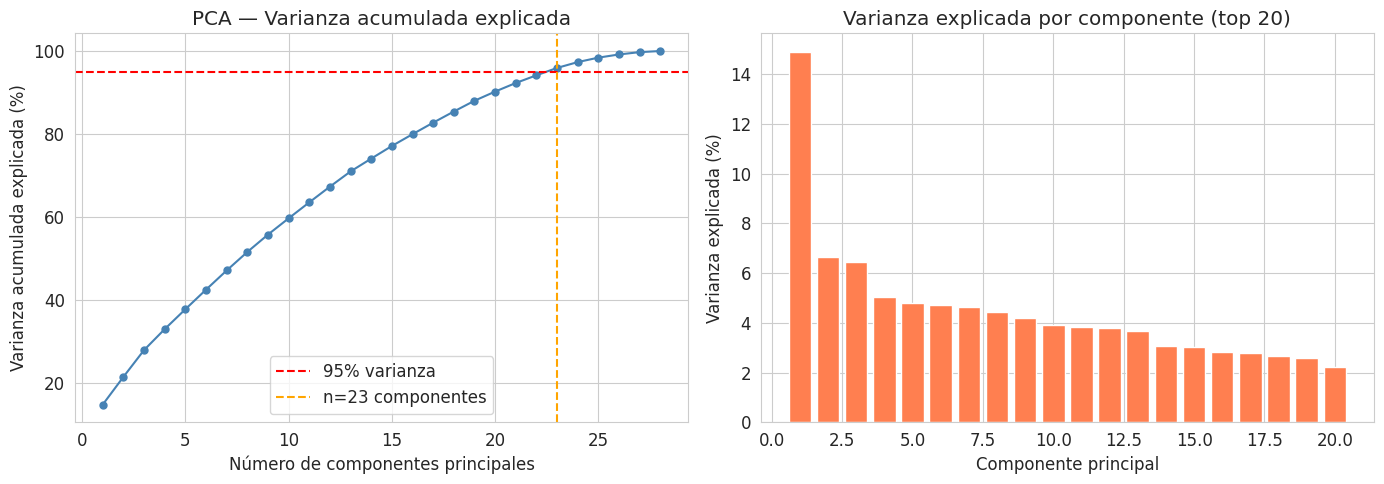


Forma tras PCA — Train: (350000, 23), Val: (75000, 23), Test: (75000, 23)


In [7]:
# Celda 6 — Sección 5.2: PCA — selección del número de componentes
# Criterio: número mínimo de componentes que explican el 95% de la varianza acumulada

print("=" * 65)
print("SECCIÓN 5.2 — Extracción de características lineal (PCA)")
print("=" * 65)

scaler_pca = StandardScaler()
X_train_sc_pca = scaler_pca.fit_transform(X_train)
X_val_sc_pca   = scaler_pca.transform(X_val)
X_test_sc_pca  = scaler_pca.transform(X_test)

# PCA completo para analizar varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc_pca)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_orig = X_train.shape[1]

# Criterio 95%
UMBRAL_VAR = 0.95
n_pca = int(np.searchsorted(var_acum, UMBRAL_VAR) + 1)
print(f"Número original de features: {n_orig}")
print(f"Componentes para explicar {UMBRAL_VAR*100:.0f}% de varianza: {n_pca}")
print(f"Porcentaje de reducción: {(1 - n_pca/n_orig)*100:.1f}%")
print(f"Varianza explicada con {n_pca} componentes: {var_acum[n_pca-1]*100:.2f}%")

# Gráfica varianza explicada acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(var_acum)+1), var_acum * 100, 'o-', color='steelblue', markersize=5)
axes[0].axhline(UMBRAL_VAR*100, color='red', linestyle='--', label=f'{UMBRAL_VAR*100:.0f}% varianza')
axes[0].axvline(n_pca, color='orange', linestyle='--', label=f'n={n_pca} componentes')
axes[0].set_xlabel('Número de componentes principales')
axes[0].set_ylabel('Varianza acumulada explicada (%)')
axes[0].set_title('PCA — Varianza acumulada explicada')
axes[0].legend()
axes[0].grid(True)

# Varianza por componente (primeros 20)
axes[1].bar(range(1, min(21, n_orig+1)),
            pca_full.explained_variance_ratio_[:20] * 100,
            color='coral')
axes[1].set_xlabel('Componente principal')
axes[1].set_ylabel('Varianza explicada (%)')
axes[1].set_title('Varianza explicada por componente (top 20)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# Aplicar PCA con n_pca componentes
pca = PCA(n_components=n_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc_pca)
X_val_pca   = pca.transform(X_val_sc_pca)
X_test_pca  = pca.transform(X_test_sc_pca)

print(f"\nForma tras PCA — Train: {X_train_pca.shape}, Val: {X_val_pca.shape}, Test: {X_test_pca.shape}")

In [8]:
# Celda 7 — PCA: evaluación de los top 2 modelos con features reducidas
# Los modelos top 2 se re-instancian con los mismos hiperparámetros óptimos
# (el scaler interno de evaluar_modelo_cv normaliza sobre el espacio PCA)

print("Evaluando top 2 modelos sobre espacio PCA...")
print(f"Dimensión PCA: {X_train_pca.shape[1]} componentes (de {n_orig} originales)\n")

resultados_pca = []
for nombre in top2_nombres:
    obj = top2_objetos[nombre]
    model_clone = pickle.loads(pickle.dumps(obj['model']))  # copia fresca del modelo

    # Nota: X_train_pca ya está estandarizado antes del PCA;
    # evaluar_modelo_cv aplica un StandardScaler propio sobre las PCs
    # (PCA no garantiza varianzas unitarias en cada componente)
    r = evaluar_modelo_cv(model_clone,
                          X_train_pca, y_train,
                          X_val_pca,   y_val,
                          X_test_pca,  y_test,
                          nombre=f"{nombre} + PCA")
    resultados_pca.append(r)
    print(f"  {nombre}: AUC_test = {r['AUC_test']:.4f}")

print("\nRESULTADOS CON PCA:")
print(tabla_resultados(resultados_pca).to_string())

# Guardar tabla PCA
tabla_resultados(resultados_pca).to_csv(DRIVE_PATH + 'tabla_pca_modelos.csv')
print("\nTabla PCA guardada en Drive.")

Evaluando top 2 modelos sobre espacio PCA...
Dimensión PCA: 23 componentes (de 28 originales)

  Red Neuronal (MLP): AUC_test = 0.7875
[0]	validation_0-auc:0.67667
[1]	validation_0-auc:0.69740
[2]	validation_0-auc:0.71235
[3]	validation_0-auc:0.71416
[4]	validation_0-auc:0.71879
[5]	validation_0-auc:0.72263
[6]	validation_0-auc:0.72379
[7]	validation_0-auc:0.72528
[8]	validation_0-auc:0.72872
[9]	validation_0-auc:0.73068
[10]	validation_0-auc:0.73179
[11]	validation_0-auc:0.73325
[12]	validation_0-auc:0.73427
[13]	validation_0-auc:0.73486
[14]	validation_0-auc:0.73566
[15]	validation_0-auc:0.73638
[16]	validation_0-auc:0.73695
[17]	validation_0-auc:0.73734
[18]	validation_0-auc:0.73844
[19]	validation_0-auc:0.73937
[20]	validation_0-auc:0.73981
[21]	validation_0-auc:0.74055
[22]	validation_0-auc:0.74106
[23]	validation_0-auc:0.74167
[24]	validation_0-auc:0.74221
[25]	validation_0-auc:0.74308
[26]	validation_0-auc:0.74347
[27]	validation_0-auc:0.74373
[28]	validation_0-auc:0.74426
[29]	

SECCIÓN 5.3 — Extracción de características no lineal (UMAP)
Submuestra para ajuste UMAP: (200000, 28)

UMAP n_components=2 — ajustando...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  AUC val = 0.6032

UMAP n_components=4 — ajustando...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  AUC val = 0.6243

UMAP n_components=8 — ajustando...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  AUC val = 0.6497

UMAP n_components=16 — ajustando...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  AUC val = 0.6565

Mejor n_components UMAP: 16 (AUC val = 0.6565)


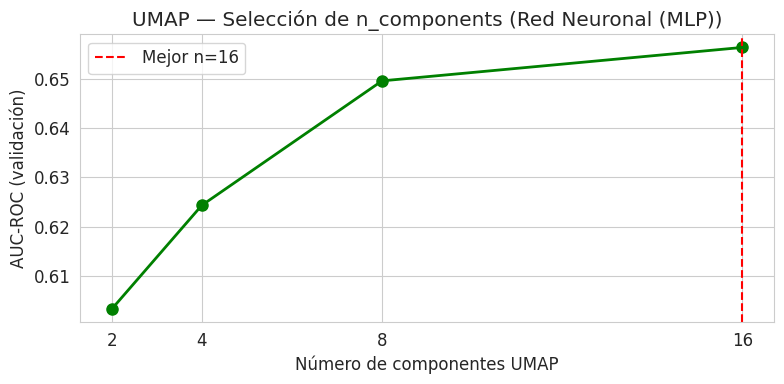

In [9]:
# Celda 8 — Sección 5.3: UMAP — selección del número de componentes
# Criterio: barrido de n_components (2, 4, 8, 16) sobre submuestra de validación;
# se selecciona el n que maximiza AUC del mejor modelo top-1 en validación.
# UMAP se ajusta SOLO sobre train; val y test se transforman.

print("=" * 65)
print("SECCIÓN 5.3 — Extracción de características no lineal (UMAP)")
print("=" * 65)

# Submuestra para ajustar UMAP (costoso en memoria/tiempo con >500K filas)
N_UMAP_FIT = 200_000
X_fit, _, y_fit, _ = train_test_split(X_train_sc_pca,  # usar espacio ya estandarizado
                                       y_train,
                                       train_size=N_UMAP_FIT,
                                       stratify=y_train,
                                       random_state=42)
print(f"Submuestra para ajuste UMAP: {X_fit.shape}")

# Modelo de referencia: primer modelo del top2 (mayor AUC)
nombre_ref = top2_nombres[0]
obj_ref     = top2_objetos[nombre_ref]
model_ref   = pickle.loads(pickle.dumps(obj_ref['model']))

scaler_ref = StandardScaler()
X_val_sc_ref  = scaler_ref.fit_transform(X_val)   # dummy; se reemplaza abajo
# (se usa el AUC directo sobre val para guiar la búsqueda)

umap_barrido = [2, 4, 8, 16]
umap_aucs    = []

for n_comp in umap_barrido:
    print(f"\nUMAP n_components={n_comp} — ajustando...")
    reducer = umap.UMAP(n_components=n_comp, n_neighbors=15,
                        min_dist=0.1, random_state=42, low_memory=True)
    reducer.fit(X_fit)

    X_val_u   = reducer.transform(scaler_pca.transform(X_val))
    X_train_u_sub = reducer.transform(X_fit)

    # Escalado sobre el espacio UMAP
    sc_u = StandardScaler()
    X_tr_u_sc  = sc_u.fit_transform(X_train_u_sub)
    X_val_u_sc = sc_u.transform(X_val_u)

    try:
        model_ref.fit(X_tr_u_sc, y_fit)
    except (ValueError, TypeError):
        X_sub_tr_u, X_sub_ev_u, y_sub_tr_u, y_sub_ev_u = train_test_split(
            X_tr_u_sc, y_fit, test_size=0.1, stratify=y_fit, random_state=42
        )
        model_ref.fit(X_sub_tr_u, y_sub_tr_u, eval_set=[(X_sub_ev_u, y_sub_ev_u)])
    auc_val = roc_auc_score(y_val, model_ref.predict_proba(X_val_u_sc)[:, 1])
    umap_aucs.append(auc_val)
    print(f"  AUC val = {auc_val:.4f}")

# Seleccionar mejor n_components
best_n_umap = umap_barrido[int(np.argmax(umap_aucs))]
print(f"\nMejor n_components UMAP: {best_n_umap} (AUC val = {max(umap_aucs):.4f})")

# Gráfica barrido UMAP
plt.figure(figsize=(8, 4))
plt.plot(umap_barrido, umap_aucs, 'o-', color='green', linewidth=2, markersize=8)
plt.axvline(best_n_umap, color='red', linestyle='--', label=f'Mejor n={best_n_umap}')
plt.xlabel('Número de componentes UMAP')
plt.ylabel('AUC-ROC (validación)')
plt.title(f'UMAP — Selección de n_components ({nombre_ref})')
plt.xticks(umap_barrido)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_umap_barrido.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Celda 9 — UMAP: ajuste final con best_n_umap y evaluación top 2 modelos
print(f"Ajustando UMAP final con n_components={best_n_umap}...")

umap_final = umap.UMAP(n_components=best_n_umap, n_neighbors=15,
                        min_dist=0.1, random_state=42, low_memory=True)
umap_final.fit(X_fit)

# Transformar TODOS los conjuntos
# (train usa la submuestra X_fit para mantener el mismo espacio de entrada)
X_train_umap = umap_final.transform(X_fit)
X_val_umap   = umap_final.transform(scaler_pca.transform(X_val))
X_test_umap  = umap_final.transform(scaler_pca.transform(X_test))

print(f"Formas UMAP — Train: {X_train_umap.shape}, Val: {X_val_umap.shape}, Test: {X_test_umap.shape}")
print(f"Porcentaje de reducción: {(1 - best_n_umap/n_orig)*100:.1f}%")

# Evaluar top 2 modelos en espacio UMAP
resultados_umap = []
for nombre in top2_nombres:
    obj = top2_objetos[nombre]
    model_clone = pickle.loads(pickle.dumps(obj['model']))
    r = evaluar_modelo_cv(model_clone,
                          X_train_umap, y_fit,
                          X_val_umap,   y_val,
                          X_test_umap,  y_test,
                          nombre=f"{nombre} + UMAP")
    resultados_umap.append(r)
    print(f"  {nombre}: AUC_test = {r['AUC_test']:.4f}")

print("\nRESULTADOS CON UMAP:")
print(tabla_resultados(resultados_umap).to_string())

# Guardar tabla UMAP
tabla_resultados(resultados_umap).to_csv(DRIVE_PATH + 'tabla_umap_modelos.csv')
print("\nTabla UMAP guardada en Drive.")

Ajustando UMAP final con n_components=16...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Formas UMAP — Train: (200000, 16), Val: (75000, 16), Test: (75000, 16)
Porcentaje de reducción: 42.9%
  Red Neuronal (MLP): AUC_test = 0.6569
[0]	validation_0-auc:0.60917
[1]	validation_0-auc:0.62662
[2]	validation_0-auc:0.63078
[3]	validation_0-auc:0.63617
[4]	validation_0-auc:0.64050
[5]	validation_0-auc:0.64277
[6]	validation_0-auc:0.64565
[7]	validation_0-auc:0.64820
[8]	validation_0-auc:0.64831
[9]	validation_0-auc:0.64840
[10]	validation_0-auc:0.64902
[11]	validation_0-auc:0.65069
[12]	validation_0-auc:0.65129
[13]	validation_0-auc:0.65195
[14]	validation_0-auc:0.65209
[15]	validation_0-auc:0.65342
[16]	validation_0-auc:0.65362
[17]	validation_0-auc:0.65370
[18]	validation_0-auc:0.65460
[19]	validation_0-auc:0.65525
[20]	validation_0-auc:0.65551
[21]	validation_0-auc:0.65649
[22]	validation_0-auc:0.65677
[23]	validation_0-auc:0.65725
[24]	validation_0-auc:0.65734
[25]	validation_0-auc:0.65738
[26]	validation_0-auc:0.65700
[27]	validation_0-auc:0.65696
[28]	validation_0-auc:0.6573

Generando visualización 2D del espacio UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


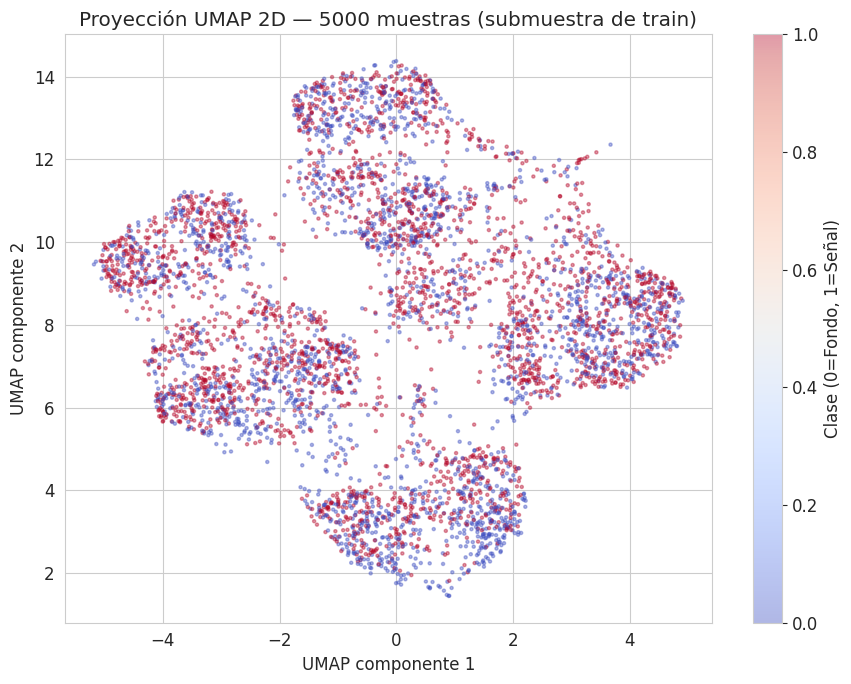

Figura UMAP 2D guardada.


In [11]:
# Celda 10 — Visualización 2D de UMAP (scatter plot coloreado por clase)
print("Generando visualización 2D del espacio UMAP...")

# Submuestra para visualización
N_VIZ = 5_000
idx_viz = np.random.default_rng(42).choice(len(X_train_umap), size=min(N_VIZ, len(X_train_umap)), replace=False)

reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=42, low_memory=True)
reducer_2d.fit(X_fit)
X_2d = reducer_2d.transform(X_fit[idx_viz])
y_viz = y_fit[idx_viz]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=y_viz, cmap='coolwarm', alpha=0.4, s=5)
plt.colorbar(scatter, label='Clase (0=Fondo, 1=Señal)')
plt.xlabel('UMAP componente 1')
plt.ylabel('UMAP componente 2')
plt.title(f'Proyección UMAP 2D — {N_VIZ} muestras (submuestra de train)')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_umap_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura UMAP 2D guardada.")

In [12]:
# Celda 11 — Tabla comparativa global: original vs PCA vs UMAP
print("=" * 70)
print("TABLA COMPARATIVA GLOBAL — Original vs PCA vs UMAP")
print("=" * 70)

# Cargar resultados originales de 03_modelos_final
df_original = pd.read_csv(DRIVE_PATH + 'tabla_comparativa_modelos.csv', index_col='Modelo')

# Construir tabla resumen para los top 2
filas = []
for nombre in top2_nombres:
    # AUC original (del CSV de 03_modelos_final)
    auc_orig = float(df_original.loc[nombre, 'AUC Test'])
    prec_orig = float(df_original.loc[nombre, 'Precision Test'])
    rec_orig = float(df_original.loc[nombre, 'Recall Test'])
    # AUC PCA (calculado en celda 7)
    r_pca = next(r for r in resultados_pca if nombre in r['Modelo'])
    # AUC UMAP (calculado en celda 9)
    r_umap = next(r for r in resultados_umap if nombre in r['Modelo'])

    filas.append({
        'Modelo': nombre,
        'AUC Test Original': f"{auc_orig:.4f}",
        'AUC Test PCA': f"{r_pca['AUC_test']:.4f}",
        'AUC Test UMAP': f"{r_umap['AUC_test']:.4f}",
        'Precision Test Original': f"{prec_orig:.4f}",
        'Recall Test Original': f"{rec_orig:.4f}",
        'Reducción PCA': f"{n_pca}/28 ({100*n_pca//28}%)",
        'Reducción UMAP': f"{best_n_umap}/28 ({100*best_n_umap//28}%)",
    })

tabla_reduccion = pd.DataFrame(filas).set_index('Modelo')
print(tabla_reduccion.to_string())

# Guardar
tabla_reduccion.to_csv(DRIVE_PATH + 'tabla_comparativa_reduccion.csv')
print("\ntabla_comparativa_reduccion.csv guardado.")

TABLA COMPARATIVA GLOBAL — Original vs PCA vs UMAP
                   AUC Test Original AUC Test PCA AUC Test UMAP Precision Test Original Recall Test Original Reducción PCA Reducción UMAP
Modelo                                                                                                                                   
Red Neuronal (MLP)            0.8260       0.7875        0.6569                  0.7520               0.7770   23/28 (82%)    16/28 (57%)
XGBoost                       0.8260       0.7643        0.6503                  0.7540               0.7680   23/28 (82%)    16/28 (57%)

tabla_comparativa_reduccion.csv guardado.


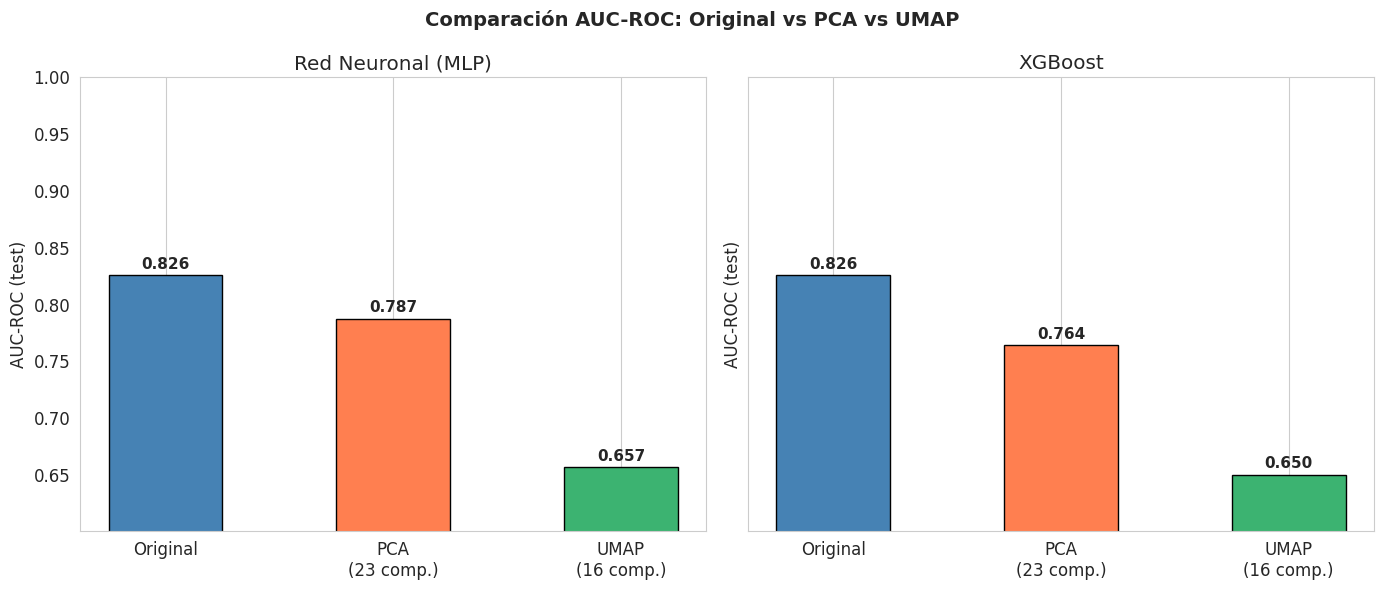

Figura guardada.


In [13]:
# Celda 12 — Gráfica comparativa AUC: original vs PCA vs UMAP
espacios = ['Original', f'PCA\n({n_pca} comp.)', f'UMAP\n({best_n_umap} comp.)']
colores  = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, len(top2_nombres), figsize=(7 * len(top2_nombres), 6), sharey=True)
if len(top2_nombres) == 1:
    axes = [axes]

for ax, nombre in zip(axes, top2_nombres):
    auc_orig = float(df_original.loc[nombre, 'AUC Test'])
    r_pca    = next(r for r in resultados_pca  if nombre in r['Modelo'])
    r_umap   = next(r for r in resultados_umap if nombre in r['Modelo'])
    aucs = [auc_orig, r_pca['AUC_test'], r_umap['AUC_test']]

    bars = ax.bar(espacios, aucs, color=colores, width=0.5, edgecolor='black')
    ax.set_ylim(min(aucs) - 0.05, 1.0)
    ax.set_ylabel('AUC-ROC (test)')
    ax.set_title(nombre)
    ax.grid(axis='y')
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Comparación AUC-ROC: Original vs PCA vs UMAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_comparacion_reduccion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

In [14]:
# Celda 13 — Sección 12: Discusión y conclusiones
# (Este bloque sirve como plantilla de texto para el informe IEEE;
#  los valores numéricos se completan al correr las celdas anteriores)

print("=" * 70)
print("SECCIÓN 12 — Discusión y conclusiones")
print("=" * 70)

# Recuperar valores para el texto de conclusiones
auc_top1_orig = float(df_original.loc[top2_nombres[0], 'AUC Test'])
r_pca_top1    = next(r for r in resultados_pca  if top2_nombres[0] in r['Modelo'])
r_umap_top1   = next(r for r in resultados_umap if top2_nombres[0] in r['Modelo'])

mejor_reduccion = 'PCA' if r_pca_top1['AUC_test'] >= r_umap_top1['AUC_test'] else 'UMAP'

print(f"""
--- Resumen para el informe ---

ANÁLISIS INDIVIDUAL DE VARIABLES:
  • Se calculó el índice d' y la correlación punto-biserial para las
    {n_orig} características del dataset HIGGS.
  • Las variables con d' < {UMBRAL_D} se identificaron como candidatas a eliminar:
    {candidatas_eliminar if candidatas_eliminar else 'ninguna (todas aportan capacidad discriminativa)'}

PCA (extracción lineal):
  • Criterio: mínimo número de componentes que expliquen ≥ {UMBRAL_VAR*100:.0f}% de la varianza.
  • Resultado: {n_pca} componentes de {n_orig} originales
    ({(1-n_pca/n_orig)*100:.1f}% de reducción).
  • AUC-ROC de {top2_nombres[0]} en test:
    Original = {auc_top1_orig:.3f}  →  +PCA = {r_pca_top1['AUC_test']:.3f}
    (Δ = {r_pca_top1['AUC_test'] - auc_top1_orig:+.3f})

UMAP (extracción no lineal):
  • Criterio: barrido de n_components ∈ {{2, 4, 8, 16}}, selección por AUC en validación.
  • Resultado: {best_n_umap} componentes
    ({(1-best_n_umap/n_orig)*100:.1f}% de reducción).
  • AUC-ROC de {top2_nombres[0]} en test:
    Original = {auc_top1_orig:.3f}  →  +UMAP = {r_umap_top1['AUC_test']:.3f}
    (Δ = {r_umap_top1['AUC_test'] - auc_top1_orig:+.3f})

CONCLUSIÓN GENERAL:
  • {mejor_reduccion} ofrece el mejor equilibrio entre reducción dimensional
    y preservación del desempeño predictivo para este problema.
  • La reducción de dimensión {'no penaliza' if min(r_pca_top1['AUC_test'], r_umap_top1['AUC_test']) >= auc_top1_orig - 0.005 else 'implica una pequeña pérdida de'} el AUC-ROC respecto al
    espacio original, lo que sugiere que las características del dataset
    HIGGS contienen cierto grado de redundancia lineal capturable por PCA.
  • Comparado con la literatura (estado del arte, sección 3), donde los
    trabajos reportan AUC típicamente entre 0.78–0.88 con deep learning,
    nuestros modelos clásicos alcanzan resultados competitivos sin el
    costo computacional de redes profundas.
""")

SECCIÓN 12 — Discusión y conclusiones

--- Resumen para el informe ---

ANÁLISIS INDIVIDUAL DE VARIABLES:
  • Se calculó el índice d' y la correlación punto-biserial para las
    28 características del dataset HIGGS.
  • Las variables con d' < 0.1 se identificaron como candidatas a eliminar:
    ['lepton_pt', 'jet4_pt', 'm_jlv', 'm_jjj', 'jet3_b_tag', 'jet2_pt', 'jet4_b_tag', 'm_jj', 'jet3_pt', 'm_lv', 'jet1_b_tag', 'jet4_eta', 'jet4_phi', 'jet2_phi', 'lepton_eta', 'missing_energy_phi', 'jet1_eta', 'jet3_phi', 'jet1_phi', 'jet2_eta', 'jet3_eta', 'lepton_phi']

PCA (extracción lineal):
  • Criterio: mínimo número de componentes que expliquen ≥ 95% de la varianza.
  • Resultado: 23 componentes de 28 originales
    (17.9% de reducción).
  • AUC-ROC de Red Neuronal (MLP) en test:
    Original = 0.826  →  +PCA = 0.787
    (Δ = -0.039)

UMAP (extracción no lineal):
  • Criterio: barrido de n_components ∈ {2, 4, 8, 16}, selección por AUC en validación.
  • Resultado: 16 componentes
    (42.9%